# 15 - Skill Value Ranking

# Module 1.5 — Skill Value Ranking

## Purpose
This module derives a **Skill Value Ranking** that summarises how individual skills are associated with salary outcomes **as implied by the fitted salary response model**. The ranking is intended as a **descriptive market signal**, not a causal estimate of skill returns.

All values are **conditional on the full set of controls already included in the model**, including job title, seniority, industry, geography, and company characteristics.

---

## Conceptual Framing
Skills enter the salary model through a **Principal Component Analysis (PCA)** representation to manage high dimensionality and multicollinearity. The salary model therefore learns effects at the **PCA component level**, not at the raw skill level.

This module **back-projects those learned component-level effects** onto individual skills using PCA loadings, producing a coherent and model-consistent skill-level signal.

---

## Method Overview
1. Extract PCA component importance from the fitted salary model  
2. Combine component importance with PCA skill loadings  
3. Aggregate signed contributions across components for each skill  
4. Normalise results into a **Global Skill Value Index**

No additional models are trained, and no explainability tools are re-run.

---

## Output Definition
**Global Skill Value Index (GSVI)**  
A unitless, relative index representing the model-implied association between a skill and predicted salary.

- Higher values indicate stronger positive association with salary
- Negative values indicate negative association
- Values are interpretable **only in relative terms**

---

## Scope and Constraints
- Global aggregation only
- No stratification by role, city, industry, or seniority
- No causal interpretation
- No monetary conversion
- No uncertainty estimation

---

## Interpretation Guidelines
- Rankings reflect the structure of the observed job market data
- Results depend on how skills co-occur in real job postings
- Skills should be interpreted as **signals within bundles**, not isolated levers

---

## Role in the Project
This module completes **Chapter 1** by translating the salary model into a human-interpretable skill signal.  
Its outputs serve as **inputs to Chapter 2**, where skills are re-contextualised within job–skill graphs and ecosystem structure.



## Set Up
* Libraries
* Paths
* Load models
* Load data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
import shap
from pathlib import Path
from sklearn.model_selection import train_test_split
import joblib

In [2]:
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [3]:
from src.job_intel.config import (CH1_PROCESSED_SALARY_MODEL_PCA_DF, MODELS_DIR)
OUT_DIR = project_root / "docs/narrative/figures/ch1_explainability"
SALARY_MODEL_PATH = MODELS_DIR / "salary_model_v4.pkl"
PCA_MODEL_PATH = MODELS_DIR/ "skill_pca_v1.pkl"

In [4]:
salary_model = joblib.load(SALARY_MODEL_PATH)
pca_model    = joblib.load(PCA_MODEL_PATH)

In [5]:
df_ch0 = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_PCA_DF)
response = df_ch0['sal_mean']
features = df_ch0[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_rich_code', 
            # Skills
            'skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC4', 'skill_PC5', 
            'skill_PC6', 'skill_PC7', 'skill_PC8', 'skill_PC9', 'skill_PC10'
            ]]

cat_cols = ['size_code','sector_code','state_code','ownership_code',
            'seniority_code','title_rich_code']
features[cat_cols] = features[cat_cols].astype('category')

X_train, X_test, y_train, y_test = train_test_split(features, response, test_size=0.20, random_state=101)

/var/folders/vx/4t7xz04d6_39xszmh_6hq4br0000gn/T/ipykernel_61585/2866201311.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[cat_cols] = features[cat_cols].astype('category')


## Skills loading

In [6]:
skills = [# Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none'
            ]

loadings = pd.DataFrame(
    pca_model.components_.T,
    index=skills,
    columns=[f"PC{i+1}" for i in range(10)]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
core_programming__basic,0.423727,-0.124008,0.285786,-0.262649,-0.003284,-0.091759,0.341033,-0.435815,0.247358,-0.292232
core_programming__intermediate,0.139735,-0.102665,-0.014122,0.038017,0.030661,0.038589,0.050609,-0.017441,0.075627,-0.131663
core_programming__advanced,0.001854,-0.003711,0.001158,0.000208,0.000832,0.001625,0.000868,0.002211,0.003578,-0.001169
data_engineering_pipelines__basic,0.007271,0.007022,-0.013100,0.010150,0.000656,0.004248,0.008360,0.007913,0.015081,-0.000478
data_engineering_pipelines__intermediate,0.438001,-0.114083,-0.254168,0.202403,-0.069888,0.273704,-0.096935,0.225777,-0.291864,-0.367351
data_engineering_pipelines__advanced,0.223082,-0.099995,0.018525,0.181114,-0.100865,0.233552,0.038472,-0.239834,0.042394,0.099825
ml_ai__basic,0.145699,-0.120309,0.432614,-0.063083,-0.070631,-0.002067,-0.404033,0.047760,-0.222949,0.059303
ml_ai__intermediate,0.152610,-0.123969,0.415988,-0.115643,-0.050566,-0.051853,-0.415518,0.028178,-0.149255,0.041405
ml_ai__advanced,0.081754,-0.110176,0.208863,-0.006450,-0.039371,0.017795,-0.178220,-0.017534,-0.044040,0.071349
analytics_stats__basic,0.180525,0.289254,0.396368,0.010952,-0.143344,0.302165,0.472641,0.564250,-0.028823,0.185006


## SHAP

In [7]:
explainer = shap.TreeExplainer(salary_model)
shap_values = explainer(X_train)
global_shap_mean = pd.DataFrame({'features':shap_values.feature_names,
                                 'sign':shap_values.values.mean(axis = 0),
                                 'magnitude':abs(shap_values.values).mean(axis = 0),
                                 'weight' : (shap_values.values.mean(axis = 0)) * (abs(shap_values.values).mean(axis = 0))})

skill_pca = [
    'skill_PC1',
    'skill_PC2',
    'skill_PC3',
    'skill_PC4',
    'skill_PC5',
    'skill_PC6',
    'skill_PC7',
    'skill_PC8',
    'skill_PC9',
    'skill_PC10'
]

global_shap_mean = global_shap_mean[global_shap_mean['features'].isin(skill_pca)]
global_shap_mean['features'] =  global_shap_mean['features'].apply(lambda x: x.split('_')[1])


## Back-project to skill values

In [8]:
global_shap_mean.index = global_shap_mean['features']
weights = global_shap_mean['weight']
skill_values = (loadings * weights).sum(axis=1).rename('value')


In [9]:
skill_values

core_programming__basic                     2008.000659
core_programming__intermediate               294.807793
core_programming__advanced                    -0.891881
data_engineering_pipelines__basic            -11.607107
data_engineering_pipelines__intermediate     183.255350
data_engineering_pipelines__advanced         978.711940
ml_ai__basic                                 462.539702
ml_ai__intermediate                          510.453210
ml_ai__advanced                              329.722672
analytics_stats__basic                      -598.574715
analytics_stats__intermediate                 94.585173
analytics_stats__advanced                     41.449986
bi_viz__basic                                571.140503
bi_viz__intermediate                         158.239646
bi_viz__advanced                               9.796914
cloud__basic                                 456.900924
cloud__intermediate                          124.241604
cloud__advanced                               86

### Normalise the skill values (z-score)

In [10]:
skill_value_index = (skill_values - skill_values.mean()) / skill_values.std()
skill_value_df = pd.DataFrame({'skill':skill_value_index.index,
                               'value' : skill_value_index})

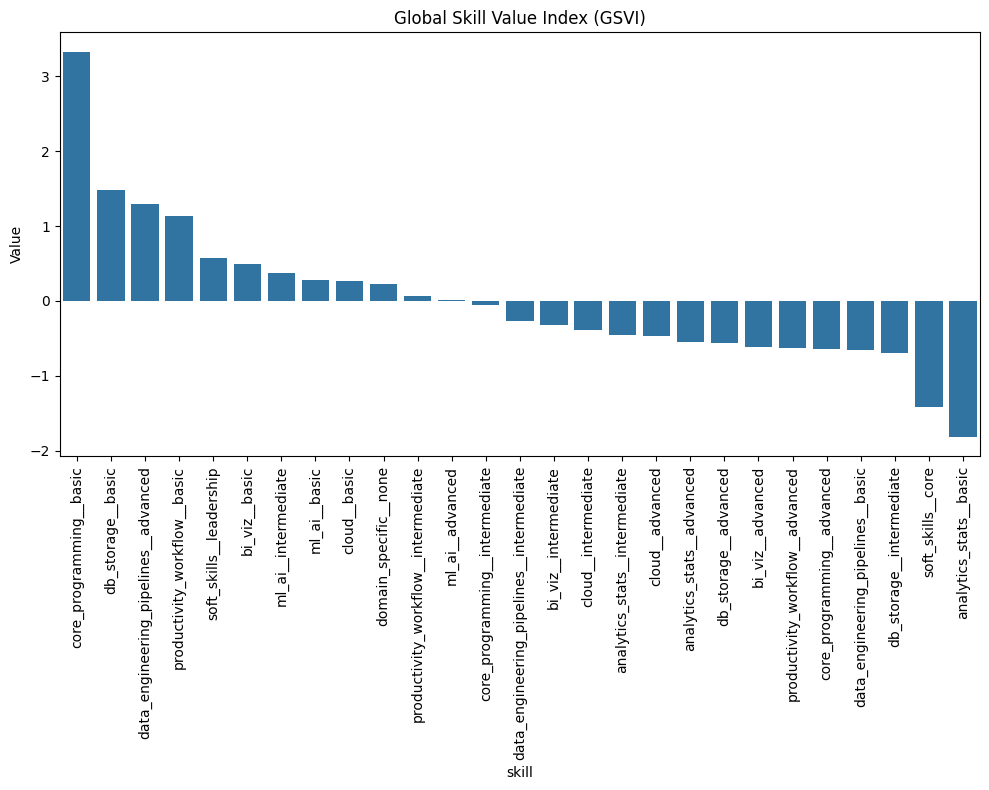

In [13]:
plt.figure(figsize=(10,8))
sns.barplot(
    data = skill_value_df.sort_values('value', ascending=False),
    x = 'skill',
    y = 'value'
)
plt.title('Global Skill Value Index (GSVI)')
plt.ylabel('Value')
plt.xticks(rotation = 90)
plt.tight_layout()
OUT_DIR = project_root / "docs/narrative/figures/ch1_explainability"
plt.savefig(OUT_DIR / "global_skill_value_index.png", dpi=300, bbox_inches="tight")

### Save table

In [ ]:
from src.job_intel.config import PROCESSED_DATA_DIR
skill_value_df.to_csv(PROCESSED_DATA_DIR / 'skill_value_index.csv', index=False)

# Closing notes
This notebook derives a global, model-consistent skill value signal from the fitted salary response model. Because skills enter the model through a PCA representation, we first quantified the importance and direction of each skill PCA axis using SHAP values. We then back-projected these component-level effects onto individual skills using the PCA loadings, aggregating each skill’s contribution across all latent dimensions. The resulting raw skill scores capture relative, conditional associations with predicted salary rather than causal effects. Finally, these scores were normalised into a Global Skill Value Index and saved as a reusable Chapter 1 artifact.